# Fed-BioMed harmonize CSV dataset with FedComBat, then train a model on harmonized dataset

Federated pre-processing prepares a distributed dataset for federated learning **without the raw data leaving the node or being shared with other nodes**. Only some statistical parameters are shared.

This example shows how to use a federated preprocessing for harmonization datasets with FedCombat method, before training a model on the harmonized dataset. The dataset used on each node is a CSV format file. The example CSV file is synthetic data with a format inspired from ADNI dataset.

FedComBat harmonizes data from the nodes to reduce site effects. Variables to harmonize are called *phenotypes* while predictive variables whose effects are modeled and preserved are called *covariates*.



## Before you start

Generate a synthetic dataset for the tutorial. Values are dummy but demonstrate clearly the action of FedComBat algorithm, as they include a batch effect component, which is removed by FedComBat.

In [ ]:
!python ./generate_combat_data.py

### Configure nodes by adding the previously generated datasets

```bash
# Node 1
fedbiomed node -p my-node-1 dataset add    # add batch_0.csv dataset with tag 'fedcombat-example'
fedbiomed node -p my-node-1 start

# Node 2 (optional)
fedbiomed node -p my-node-2 dataset add    # add batch_1.csv dataset with tag 'fedcombat-example'
fedbiomed node -p my-node-2 start
```

Wait until you see `Starting task manager` in each node terminal.

### Start the researcher

```bash
fedbiomed researcher start
```

## Create an experiment to train a model on the data found

Declare a torch training plan MyTrainingPlan class to send for training on the node

In [ ]:
import torch
import torch.nn as nn
from fedbiomed.common.training_plans import TorchTrainingPlan
from fedbiomed.common.datamanager import DataManager
from fedbiomed.common.dataset import TabularDataset
import pandas as pd

# Here we define the model to be used. 
# You can use any class name (here 'MyTrainingPlan')
class MyTrainingPlan(TorchTrainingPlan):
    
    # Model 
    def init_model(self, model_args):    
        model = self.Net(model_args)
        return model 
    
    
    # Dependencies
    def init_dependencies(self):
        # Here we define the custom dependencies that will be needed by our custom Dataloader
        # In this case, we need the torch Dataset and DataLoader classes
        # We need pandas to read the local .csv file at the node side
        deps = ["from fedbiomed.common.dataset import TabularDataset"]
        
        return deps
    
    class Net(nn.Module):
        def __init__(self, model_args):
            super().__init__()
            # should match the model arguments dict passed below to the experiment class
            self.fc1 = nn.Linear(model_args['in_features'], 5)
            self.fc2 = nn.Linear(5, model_args['out_features'])

        def forward(self, x):
            x = self.fc1(x)
            x = F.relu(x)
            x = self.fc2(x)
            return x

    def training_step(self, data, target):
        output = self.model().forward(data).float()
        criterion = torch.nn.MSELoss()
        loss   = criterion(output, target)
        return loss

    def training_data(self):
        x_dim = self.model_args()['in_features']
        dataset = TabularDataset(
            input_columns=['SEX','AGE','PTEDUCAT', 'CDRSB.bl'],
            target_columns='RAVLT.forgetting.bl',
            transform=lambda xs: torch.as_tensor(xs, dtype=torch.float32),
            target_transform=lambda xs: torch.as_tensor(xs, dtype=torch.float32)
        )

        train_kwargs = {'shuffle': True}
        
        return DataManager(dataset=dataset, **train_kwargs)

In [ ]:
# model parameters 
model_args = {
    'in_features': 4, 
    'out_features': 1
}

# training parameters 
training_args = {
    'loader_args': { 'batch_size': 20, }, 
    'optimizer_args': {
        'lr': 1e-3
    }, 
    'epochs': 2, 
    'dry_run': False,  
}

In [ ]:
from fedbiomed.researcher.federated_workflows import Experiment
from fedbiomed.researcher.aggregators.fedavg import FedAverage

# Calling the training data with specified tags
tags = ['fedcombat-example']
rounds = 2

exp = Experiment(tags=tags,
                 training_plan_class=MyTrainingPlan,
                 model_args=model_args,
                 training_args=training_args,
                 round_limit=rounds,
                 aggregator=FedAverage(),
                 node_selection_strategy=None,
                 save_breakpoints=True,
                 tensorboard=True
                )

In [ ]:
# Optionally save initial params to retry without introducing alea
#exp.training_plan().export_model('./fixed_initial_params')

In [ ]:
# Optionally reuse initial params to retry without introducing alea
# also fix random_seed for reproducibility
#exp.training_plan().import_model('./fixed_initial_params')

### Set pre-processing

`Phenotypes` are the variables from the dataset that are harmonized by Fed-ComBat (the features for which batch/site effects are corrected).

`Covariates` are the variables whose effects are modeled and preserved during harmonization (e.g., age, sex, diagnosis), rather than being removed.

In [ ]:
from fedbiomed.common.constants import PreprocType

# Caveat: pre-processing uses the whole dataset, even if training plan is filtering
# only some columns for training. So column numbers reference the *full* dataset
fedcombat_args = {
    # Can use numeric values
    #'covariates': [1,2],
    #'phenotypes': [3,4,5,6,7,8,9,10,11,12,13,14,15],

    # Can use label values
    'covariates': ['SEX','AGE','PTEDUCAT'],
    'phenotypes': [ 'CDRSB.bl','RAVLT.forgetting.bl' ],
    #'phenotypes': [
    #    'CDRSB.bl','ADAS11.bl','MMSE.bl','RAVLT.immediate.bl','RAVLT.learning.bl','RAVLT.forgetting.bl',
    #    'FAQ.bl','WholeBrain.bl','Ventricles.bl','Hippocampus.bl','MidTemp.bl','Entorhinal.bl',
    #],

    # Can NOT mix numeric and label in same variable
    #'covariates': [1,'AGE','PTEDUCAT'],
    #'phenotypes': ['CDRSB.bl','ADAS11.bl',6,7],

    # Can NOT mix numeric and label even in the other variable
    #'covariates': ['SEX','AGE','PTEDUCAT'],
    #'phenotypes': [4,5,6,7],

    # Optionally fix dataset training shuffle randomization for reproducibility
    #'training_args': {
    #    'random_seed': 1234,
    #} 

    # Optionally use non-default parameters for FedComBat inner biological and bias
    # models which are used for predicting harmonized values
    #
    # 'rounds': 5,  # non-default number of training rounds for the harmonization model
    # 'training_args': {
    #     'loader_args': {'batch_size': 8},
    #     'log_interval': 10,  # reasonably verbose harmonization logging
    # }

    # Optionally save harmonized data in standardized scale
    # Note: only phenotypes are standardized
    # (default: False, final data in original scale)
    #'standardize_result': True
}

# Associate a pre-processing with the experiment
# by default, when creating experiment, no pre-processing is configured
exp.set_preprocessing(PreprocType.FEDCOMBAT, fedcombat_args)

### Harmonize and train model

Once a pre-processing is configured for the experiment, federated dataset is automatically harmonized before training if needed.

In [16]:
# View initial federated dataset
exp.training_data().data()

{'NODE_e1635641-35fc-4777-968c-862f57d33adf': {'name': 'fedcombat test',
  'data_type': 'csv',
  'tags': ['fedcombat-example'],
  'description': 'fedcombat example',
  'shape': {'csv': [300, 5]},
  'dtypes': {'SEX': 'Float64',
   'AGE': 'Float64',
   'PTEDUCAT': 'Float64',
   'CDRSB.bl': 'Float64',
   'RAVLT.forgetting.bl': 'Float64'},
  'dataset_id': 'dataset_d16faba8-ef4c-46ca-8337-f3624335477c',
  'dataset_parameters': {}},
 'NODE_6abbf7a3-4460-46de-9980-fc74e15ab0fe': {'name': 'fedcombat example',
  'data_type': 'csv',
  'tags': ['fedcombat-example'],
  'description': 'fedcombat example',
  'shape': {'csv': [300, 5]},
  'dtypes': {'SEX': 'Float64',
   'AGE': 'Float64',
   'PTEDUCAT': 'Float64',
   'CDRSB.bl': 'Float64',
   'RAVLT.forgetting.bl': 'Float64'},
  'dataset_id': 'dataset_360eebff-c98a-4669-b946-a3cdf39e4e7c',
  'dataset_parameters': {}}}

In [ ]:
# First training round: needs pre-preprocessing
exp.run_once(increase=True)

Harmonized dataset is saved on the nodes, and federated dataset is updated on the researcher
Harmonized dataset is not searchable by tags, as it is mostly meant to be used within the context of the current experiment.

In [18]:
# View updated federated harmonized dataset
exp.training_data().data()

{'NODE_e1635641-35fc-4777-968c-862f57d33adf': {'researcher_id': 'RESEARCHER_b4c8799a-4384-418a-93ad-02e17362de14',
  'experiment_id': 'exper_2342ab8b-abed-45aa-9a64-e05475cb0035',
  'processing_id': 'preproc_5e6d77b8-bec1-4c6d-adef-2cbeeb87b632',
  'parent_dataset_id': 'dataset_d16faba8-ef4c-46ca-8337-f3624335477c',
  'shape': {'csv': [300, 5]},
  'dtypes': {'SEX': 'Float64',
   'AGE': 'Float64',
   'PTEDUCAT': 'Float64',
   'CDRSB.bl': 'Float64',
   'RAVLT.forgetting.bl': 'Float64'},
  'name': 'FedComBat from fedcombat test',
  'data_type': 'csv',
  'description': 'Harmonized with FedComBat from fedcombat example',
  'dataset_id': 'dynamic_dataset_c2cc016c-8934-4fdc-a701-f74a16ceba83',
  'dataset_parameters': {}},
 'NODE_6abbf7a3-4460-46de-9980-fc74e15ab0fe': {'researcher_id': 'RESEARCHER_b4c8799a-4384-418a-93ad-02e17362de14',
  'experiment_id': 'exper_2342ab8b-abed-45aa-9a64-e05475cb0035',
  'processing_id': 'preproc_5e6d77b8-bec1-4c6d-adef-2cbeeb87b632',
  'parent_dataset_id': 'data

This is basically how pre-processing is used for an experiment: setup a preprocessing for the experiment, then everything is automatic !

## Compare initial and harmonized datasets

Once datasets are harmonized, view data from initial, standardized and harmonized datasets.

Of course, this works only in *demo setups where all data is local and can be accessed simultaneously*.

In [ ]:
import numpy as np

def load_combat_data_from_csv(file1, file2, x_cols=None, y_cols=None):
    """
    Reads two CSV and returns a dict in a format close to simulate_combat_data.

    Parameters
    ----------
    file1, file2 : str
        Path to the two CSV files
    x_cols : list[str]
        Columns used for X.
    y_cols : list[str]
        Columns used for Y.

    Returns
    --------
    dict with
        X : (n_samples_total, len(x_cols))
        Y : (n_samples_total, len(y_cols))
        batch : (n_samples_total,) with 0 pour file1 et 1 for file2
    """
    x_cols = x_cols or ["COV1", "COV2"]
    y_cols = y_cols or ["PHE1"]

    df1 = pd.read_csv(file1)
    df2 = pd.read_csv(file2)

    required_cols = set(x_cols + y_cols)
    missing_1 = sorted(required_cols - set(df1.columns))
    missing_2 = sorted(required_cols - set(df2.columns))

    if missing_1:
        raise ValueError(f"Missing columns in file1: {missing_1}")
    if missing_2:
        raise ValueError(f"Missing columns in file2: {missing_2}")

    X1 = df1[x_cols].to_numpy(dtype=float)
    X2 = df2[x_cols].to_numpy(dtype=float)
    Y1 = df1[y_cols].to_numpy(dtype=float)
    Y2 = df2[y_cols].to_numpy(dtype=float)

    X = np.vstack([X1, X2])
    Y = np.vstack([Y1, Y2])
    batch = np.concatenate([
        np.zeros(len(df1), dtype=int),
        np.ones(len(df2), dtype=int),
    ])

    return {
        "X": X,
        "Y": Y,
        "batch": batch,
    }

def standardize_combat_data(raw_data, eps=1e-12):
    """
    Standardize X and Y from load_combat_data_from_csv output.

    Uses population standard deviation (ddof=0) and preserves geometry.

    Parameters
    ----------
    raw_data : dict
        Dictionary containing keys 'X', 'Y', and 'batch'.
    eps : float
        Small value to avoid division by zero for constant columns.

    Returns
    -------
    dict
        Standardized data with same keys and shapes as input.
    """
    if not all(k in raw_data for k in ("X", "Y", "batch")):
        raise ValueError("raw_data must contain keys: 'X', 'Y', 'batch'")

    X = np.asarray(raw_data["X"], dtype=float)
    Y = np.asarray(raw_data["Y"], dtype=float)
    batch = np.asarray(raw_data["batch"])

    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("'X' and 'Y' must be 2D arrays")
    if len(X) != len(Y) or len(batch) != len(X):
        raise ValueError("Inconsistent number of samples between X, Y, and batch")

    x_mean = X.mean(axis=0)
    x_std = X.std(axis=0, ddof=0)  # population std
    x_std = np.where(x_std < eps, 1.0, x_std)

    y_mean = Y.mean(axis=0)
    y_std = Y.std(axis=0, ddof=0)  # population std
    y_std = np.where(y_std < eps, 1.0, y_std)

    X_std = (X - x_mean) / x_std
    Y_std = (Y - y_mean) / y_std

    return {
        "X": X_std,
        "Y": Y_std,
        "batch": batch,
    }

In [ ]:
raw_combat_data = load_combat_data_from_csv("./batch_0.csv",
                          "./batch_1.csv",
                          ['SEX','AGE','PTEDUCAT'],
                          [ 'CDRSB.bl','RAVLT.forgetting.bl' ]
)
combat_data = standardize_combat_data(raw_combat_data)

In [ ]:
preproc_id = list(exp.training_data().data().values())[0]['processing_id']

**Replace paths with the correct path values for the nodes you initially declared**

In [ ]:
# Replace with the correct path values for the nodes you initially declared
path_to_first_node = "../../../../my-node-1"
path_to_second_node = "../../../../my-node-2"

harmonized_data = load_combat_data_from_csv(f"{path_to_first_node}/var/data/batch_0_harmonized_{preproc_id}.csv",
                          f"{path_to_second_node}/var/data/batch_1_harmonized_{preproc_id}.csv",
                          ['SEX','AGE','PTEDUCAT'],
                          [ 'CDRSB.bl','RAVLT.forgetting.bl' ]
)

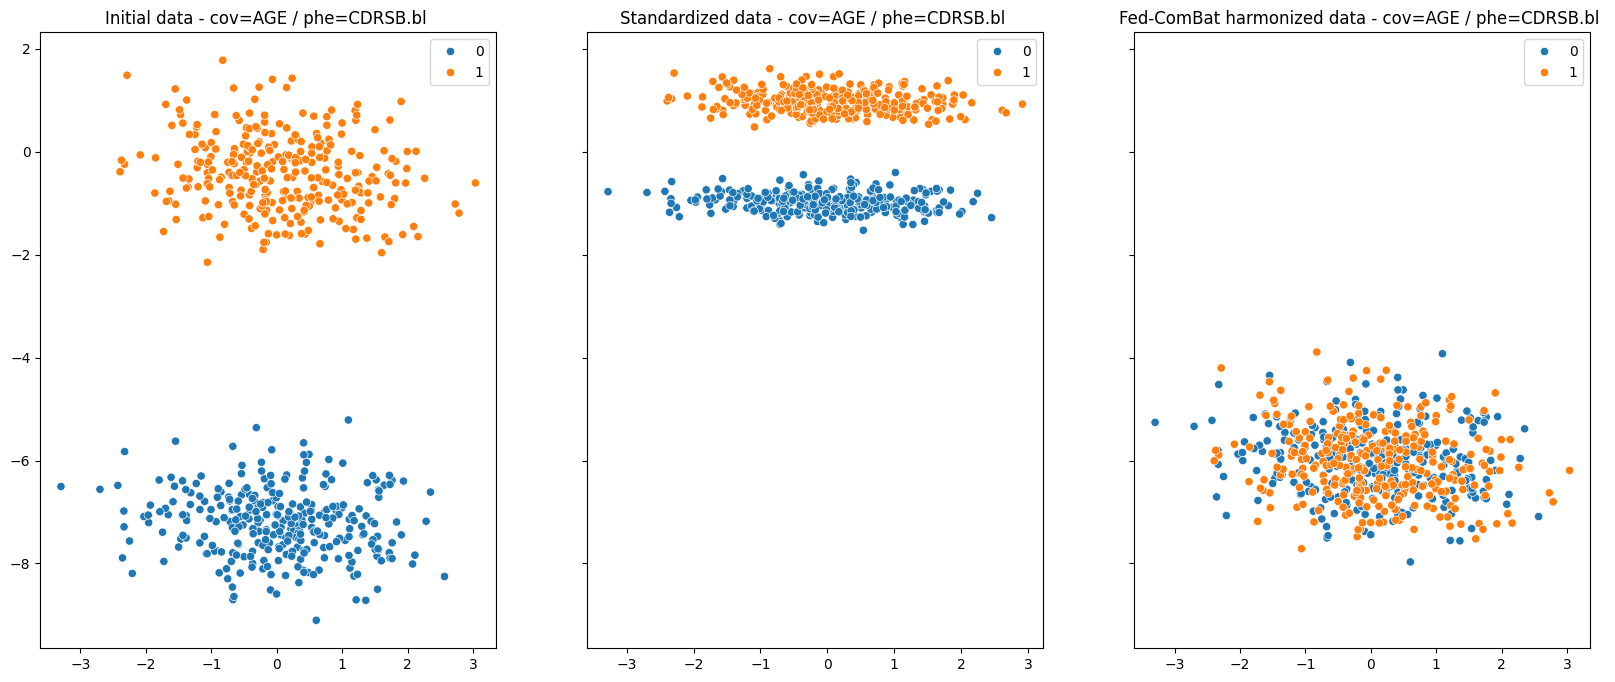

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

with torch.no_grad():
    f, axs = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
    
    sns.scatterplot(x=raw_combat_data['X'][:, 1], y=raw_combat_data['Y'][:, 0], hue=raw_combat_data['batch'], ax=axs[0])
    sns.scatterplot(x=combat_data['X'][:, 1], y=combat_data['Y'][:, 0], hue=combat_data['batch'], ax=axs[1])
    sns.scatterplot(x=harmonized_data['X'][:, 1], y=harmonized_data['Y'][:, 0], hue=harmonized_data['batch'], ax=axs[2])
    axs[0].set_title("Initial data - cov=AGE / phe=CDRSB.bl ")
    axs[1].set_title("Standardized data - cov=AGE / phe=CDRSB.bl ")
    axs[2].set_title("Fed-ComBat harmonized data - cov=AGE / phe=CDRSB.bl ")

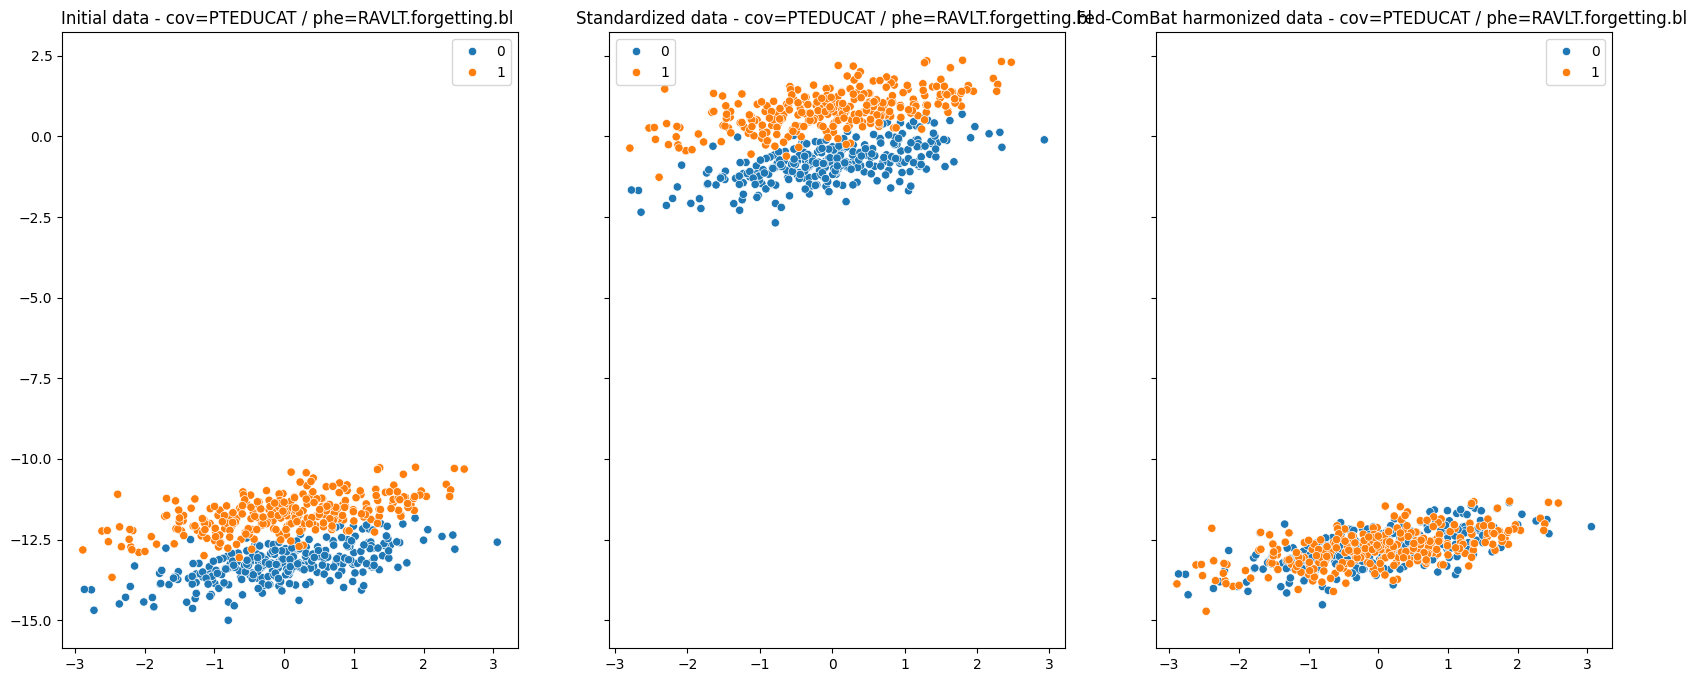

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

with torch.no_grad():
    f, axs = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
    
    sns.scatterplot(x=raw_combat_data['X'][:, 2], y=raw_combat_data['Y'][:, 1], hue=raw_combat_data['batch'], ax=axs[0])
    sns.scatterplot(x=combat_data['X'][:, 2], y=combat_data['Y'][:, 1], hue=combat_data['batch'], ax=axs[1])
    sns.scatterplot(x=harmonized_data['X'][:, 2], y=harmonized_data['Y'][:, 1], hue=harmonized_data['batch'], ax=axs[2])
    axs[0].set_title("Initial data - cov=PTEDUCAT / phe=RAVLT.forgetting.bl ")
    axs[1].set_title("Standardized data - cov=PTEDUCAT / phe=RAVLT.forgetting.bl ")
    axs[2].set_title("Fed-ComBat harmonized data - cov=PTEDUCAT / phe=RAVLT.forgetting.bl ")

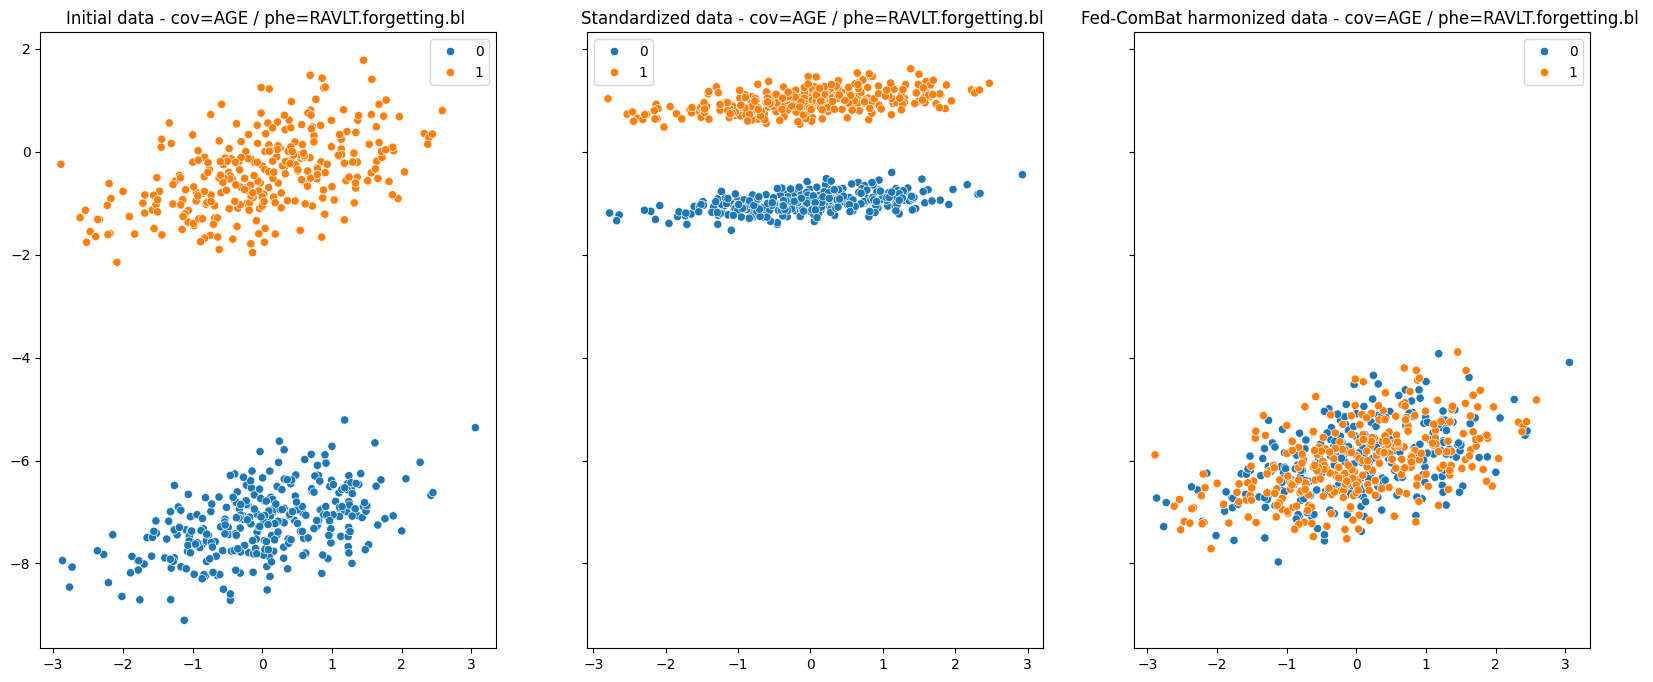

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

with torch.no_grad():
    f, axs = plt.subplots(1, 3, figsize=(20, 8), sharey=True)
    
    sns.scatterplot(x=raw_combat_data['X'][:, 2], y=raw_combat_data['Y'][:, 0], hue=raw_combat_data['batch'], ax=axs[0])
    sns.scatterplot(x=combat_data['X'][:, 2], y=combat_data['Y'][:, 0], hue=combat_data['batch'], ax=axs[1])
    sns.scatterplot(x=harmonized_data['X'][:, 2], y=harmonized_data['Y'][:, 0], hue=harmonized_data['batch'], ax=axs[2])
    axs[0].set_title("Initial data - cov=AGE / phe=RAVLT.forgetting.bl ")
    axs[1].set_title("Standardized data - cov=AGE / phe=RAVLT.forgetting.bl ")
    axs[2].set_title("Fed-ComBat harmonized data - cov=AGE / phe=RAVLT.forgetting.bl ")